# 02 - Representations & Baselines (the core comparison)

**Phase 2.** The central experiment: every classifier against every text representation.

- **4 classifiers**: Multinomial Naive Bayes, Logistic Regression, Linear SVM, XGBoost.
- **3 representation strategies** evaluated at **4 vectorizer settings** (the n-gram strategy
  is tested at two levels, as in the approved proposal): Bag-of-Words, TF-IDF unigram,
  TF-IDF n-gram (uni+bi), TF-IDF n-gram (uni+bi+tri).
- **= 16 configurations.** Each is tuned with `GridSearchCV` (stratified 5-fold CV on the
  training set, scoring F1), then evaluated once on the held-out test set.

Outputs: `results/master_metrics.csv`, F1 & FPR heatmaps, ROC curves, and
`results/top_models.json` (the two best models, reused by Phases 3 & 5).

**No leakage:** each config is a `Pipeline(vectorizer -> classifier)`, so the vectorizer is
fitted on training folds only. `clean()` is deterministic per message, so applying it before
CV is safe.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")  # precede numpy/xgboost import: avoids OpenMP deadlock

import sys, json
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

from src import config
from src.preprocessing import load_dataset, make_split, clean
from src.features import bow, tfidf_unigram, tfidf_ngram
from src.models import get_models
from src.evaluation import run_master_grid, get_scores

sns.set_theme(style="whitegrid")
RESULTS = config.RESULTS_DIR
np.random.seed(config.RANDOM_SEED)
print("Results dir:", RESULTS)

Results dir: /home/sdd/Documents/ovi/final year project/results


## 1. Load data, reuse the persisted split, apply baseline cleaning

We reload the exact same split created in notebook 01. Baseline preprocessing =
lowercase + punctuation removal (no stopword removal, no stemming); Phase 3 varies these.

In [2]:
df = load_dataset()
X_train, X_test, y_train, y_test = make_split(df)   # reloads results/split_indices.npz

X_train = np.array([clean(t) for t in X_train])
X_test = np.array([clean(t) for t in X_test])

# XGBoost imbalance correction = n_negative / n_positive on the TRAIN set.
scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())
print(f"train={len(X_train)}  test={len(X_test)}")
print(f"train spam%={100*y_train.mean():.2f}  test spam%={100*y_test.mean():.2f}")
print(f"scale_pos_weight={scale_pos_weight:.3f}")

train=4126  test=1032
train spam%=12.46  test spam%=12.40
scale_pos_weight=7.027


## 2. Define the representations and models

`min_df=2` (drop terms appearing in only one message) is applied uniformly to every
vectorizer to reduce noise/dimensionality without favouring any model.

In [3]:
MIN_DF = 2
representations = {
    "bow":           lambda: bow(min_df=MIN_DF),
    "tfidf_unigram": lambda: tfidf_unigram(min_df=MIN_DF),
    "tfidf_bigram":  lambda: tfidf_ngram(max_n=2, min_df=MIN_DF),  # uni + bi
    "tfidf_trigram": lambda: tfidf_ngram(max_n=3, min_df=MIN_DF),  # uni + bi + tri
}
models = get_models(scale_pos_weight=scale_pos_weight)

n_configs = len(models) * len(representations)
print(f"{len(models)} models x {len(representations)} representations = {n_configs} configs")
print("Models:", list(models))
print("Representations:", list(representations))

4 models x 4 representations = 16 configs
Models: ['MultinomialNB', 'LogisticRegression', 'LinearSVM', 'XGBoost']
Representations: ['bow', 'tfidf_unigram', 'tfidf_bigram', 'tfidf_trigram']


## 3. Run the master grid

Tunes each config's hyperparameters by cross-validation on the training set, refits the best,
and evaluates on the test set. This is the slow cell (mostly XGBoost).

In [4]:
cv = config.get_cv(5)
results, fitted = run_master_grid(
    models, representations, X_train, y_train, X_test, y_test, cv
)

# Persist the master table (stringify the best_params dict so it survives CSV round-trip).
to_save = results.copy()
to_save["best_params"] = to_save["best_params"].astype(str)
col_order = ["model", "representation", "accuracy", "precision", "recall", "f1",
             "fpr", "auc", "cv_best_f1", "tp", "fp", "tn", "fn", "best_params"]
to_save[col_order].to_csv(RESULTS / "master_metrics.csv", index=False)
print("Saved results/master_metrics.csv")

results_sorted = results.sort_values(["f1", "fpr"], ascending=[False, True]).reset_index(drop=True)
results_sorted[["model", "representation", "accuracy", "precision", "recall",
                "f1", "fpr", "auc", "cv_best_f1"]].round(4)

[ 1/16] bow            MultinomialNB        F1=0.9317 FPR=0.0055 (0.9s)


[ 2/16] bow            LogisticRegression   F1=0.9350 FPR=0.0033 (0.7s)


[ 3/16] bow            LinearSVM            F1=0.9194 FPR=0.0066 (1.9s)


[ 4/16] bow            XGBoost              F1=0.9274 FPR=0.0055 (12.6s)


[ 5/16] tfidf_unigram  MultinomialNB        F1=0.9306 FPR=0.0033 (0.8s)


...

[14/16] tfidf_trigram  LogisticRegression   F1=0.9365 FPR=0.0066 (2.1s)


[15/16] tfidf_trigram  LinearSVM            F1=0.9478 FPR=0.0033 (2.7s)


[16/16] tfidf_trigram  XGBoost              F1=0.8880 FPR=0.0066 (131.1s)


Saved results/master_metrics.csv


,model,representation,accuracy,precision,recall,f1,fpr,auc,cv_best_f1
0,LinearSVM,tfidf_unigram,0.9874,0.9675,0.9297,0.9482,0.0044,0.9886,0.9172
1,LinearSVM,tfidf_bigram,0.9874,0.9752,0.9219,0.9478,0.0033,0.9905,0.9264
2,LinearSVM,tfidf_trigram,0.9874,0.9752,0.9219,0.9478,0.0033,0.9913,0.9223
3,LogisticRegression,tfidf_bigram,0.9864,0.9597,0.9297,0.9444,0.0055,0.9930,0.9200
4,LogisticRegression,tfidf_trigram,0.9845,0.9516,0.9219,0.9365,0.0066,0.9932,0.9185
5,LogisticRegression,bow,0.9845,0.9746,0.8984,0.9350,0.0033,0.9795,0.9107
6,LogisticRegression,tfidf_unigram,0.9835,0.9370,0.9297,0.9333,0.0088,0.9907,0.9125
7,MultinomialNB,bow,0.9835,0.9587,0.9062,0.9317,0.0055,0.9773,0.9252
8,MultinomialNB,tfidf_unigram,0.9835,0.9744,0.8906,0.9306,0.0033,0.9902,0.9178
9,XGBoost,bow,0.9826,0.9583,0.8984,0.9274,0.0055,0.9807,0.8922


## 4. F1 by model x representation

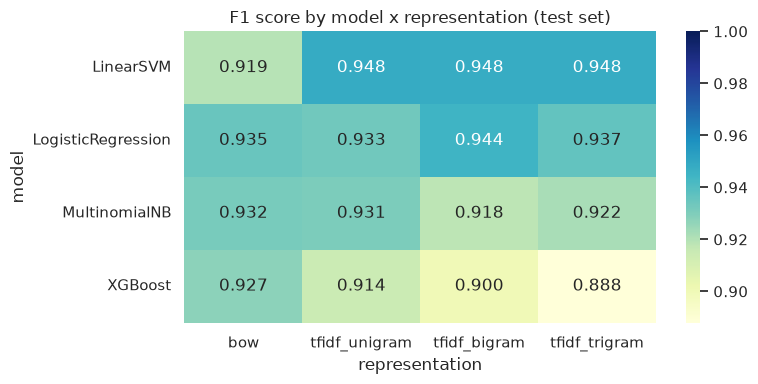

In [5]:
order = ["bow", "tfidf_unigram", "tfidf_bigram", "tfidf_trigram"]
pivot_f1 = results.pivot(index="model", columns="representation", values="f1")[order]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot_f1, annot=True, fmt=".3f", cmap="YlGnBu",
            vmin=float(pivot_f1.values.min()), vmax=1.0, ax=ax)
ax.set_title("F1 score by model x representation (test set)")
fig.tight_layout()
fig.savefig(RESULTS / "fig_master_f1_heatmap.png", dpi=150)
plt.show()

## 5. False Positive Rate by model x representation

FPR = FP / (FP + TN): legitimate messages wrongly flagged as spam. **Lower is better** and this
is the metric the supervisor weights most heavily.

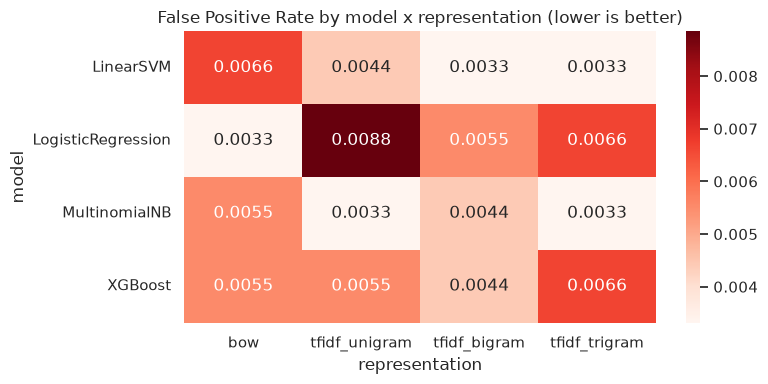

In [6]:
pivot_fpr = results.pivot(index="model", columns="representation", values="fpr")[order]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot_fpr, annot=True, fmt=".4f", cmap="Reds", ax=ax)
ax.set_title("False Positive Rate by model x representation (lower is better)")
fig.tight_layout()
fig.savefig(RESULTS / "fig_master_fpr_heatmap.png", dpi=150)
plt.show()

## 6. ROC curves (each model at its best representation)

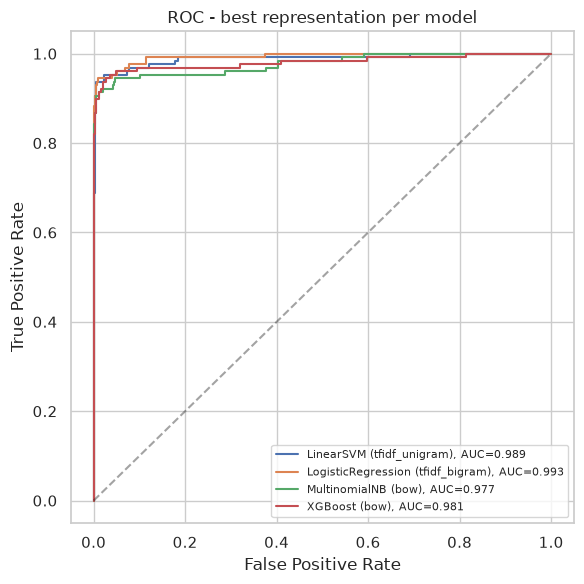

In [7]:
best_idx = results.groupby("model")["f1"].idxmax()
best_configs = results.loc[best_idx].sort_values("f1", ascending=False)

fig, ax = plt.subplots(figsize=(6, 6))
for _, r in best_configs.iterrows():
    est = fitted[(r["model"], r["representation"])]
    scores = get_scores(est, X_test)
    fpr_c, tpr_c, _ = roc_curve(y_test, scores)
    ax.plot(fpr_c, tpr_c, label=f'{r["model"]} ({r["representation"]}), AUC={r["auc"]:.3f}')

ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC - best representation per model")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS / "fig_roc.png", dpi=150)
plt.show()

## 7. Identify the top-2 models

Rank each model by its best-representation F1 (tie-break by lower FPR). The top two are carried
into the Phase-3 ablation and Phase-5 interpretability/significance analyses.

In [8]:
best_per_model = results.loc[results.groupby("model")["f1"].idxmax()]
ranking = best_per_model.sort_values(["f1", "fpr"], ascending=[False, True]).reset_index(drop=True)
print("Best configuration per model (ranked by F1, then FPR):")
print(ranking[["model", "representation", "f1", "fpr", "auc"]].round(4).to_string(index=False))

top2 = ranking.head(2)
top_models = [
    {
        "model": r["model"],
        "representation": r["representation"],
        "f1": round(float(r["f1"]), 4),
        "fpr": round(float(r["fpr"]), 4),
        "best_params": r["best_params"],
    }
    for _, r in top2.iterrows()
]
with open(RESULTS / "top_models.json", "w") as fh:
    json.dump(top_models, fh, indent=2)

print("\nTop-2 models (saved to results/top_models.json):")
for t in top_models:
    print(f"  {t['model']:20s} | {t['representation']:14s} | F1={t['f1']} | FPR={t['fpr']}")

Best configuration per model (ranked by F1, then FPR):
             model representation     f1    fpr    auc
         LinearSVM  tfidf_unigram 0.9482 0.0044 0.9886
LogisticRegression   tfidf_bigram 0.9444 0.0055 0.9930
     MultinomialNB            bow 0.9317 0.0055 0.9773
           XGBoost            bow 0.9274 0.0055 0.9807

Top-2 models (saved to results/top_models.json):
  LinearSVM            | tfidf_unigram  | F1=0.9482 | FPR=0.0044
  LogisticRegression   | tfidf_bigram   | F1=0.9444 | FPR=0.0055
